# Classify text with BERT

In this notebook, you will:

- Load the twitterParsed dataset
- Load a BERT model from TensorFlow Hub
- Build your own model by combining BERT with a classifier
- Train your own model, fine-tuning BERT as part of that
- Save your model and use it to classify sentences



# Loading of the essentials  libraries
* **tensorflow-text:** Used for text preprocessing.

* **tf-models-official:** Used to leverage pre-trained models.

* **tensorflow:** Used for manipulating and building deep learning models.

* **tensorflow_text:** The main library for deep learning tasks involving text.

* **official.nlp:** Used to apply optimization methods like AdamW.

* **os:** Used for performing operations on the file system.
* **google.colab:** Used for get the data from the google drive.

* **zipfile :** Used for extract the dataset.zip.

* **shutil:** Used for performing operations on files, like copy directory.

* **pandas:** Used for load the data and use the stratify split.

* **sklearn.model_selection :** Used for the split of the data.

* **matplot :** For visualizing the performance of the model during the history of the finetuining.

* **logger:** Used to display only important errors during output.


In [ ]:

!pip install tensorflow-text==2.14.*
!pip install "tf-models-official==2.14.*"
import tensorflow as tf
from tensorflow import keras
import tensorflow_hub as hub
import tensorflow_text as text
from tensorflow.data import AUTOTUNE
from official.nlp import optimization
from tensorflow.keras.callbacks import EarlyStopping
import os
import zipfile
from google.colab import drive
import shutil
import pandas as pd

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt # for plotting the performance between training and validation data
tf.get_logger().setLevel('ERROR')



INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 489.9/489.9 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.2 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: tf-keras
    Found existing installation: tf_keras 2.18.

#Loading of the data
The data coming from a dataset.zip released on the team course.

In [ ]:

# Mount Google Drive
drive.mount('/content/drive')

zip_path="/content/drive/MyDrive/TwitterParsed/TwitterParsed_dataset/TwitterParsed.zip"


# Destination path for extraction
extract_dir = os.path.join(os.getcwd(), 'TwitterParsed')

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Extract the zip file
try:
    print("Extracting the ZIP file...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Files extracted to: {extract_dir}")
except zipfile.BadZipFile:
    print("Error: The file is not a valid ZIP file or it is corrupted.")
except Exception as e:
    print(f"An error occurred: {e}")

Mounted at /content/drive
Extracting the ZIP file...
Files extracted to: /content/TwitterParsed


# SPLITTING OF THE DATA
For the data splitting, given the folder structure with directories 0 and 1, it is not possible to invoke a splitting method using pandas. This creates the difficulty of having to manually create splits that:

* Do not overlap between test, validation, and training sets.

* Have a balanced partition based on the target (0 or 1).

The data are loaded from data frame tensorflow, a common practice for working with big models in tensor flow. It make the process more efficient, semplify the preprocessing and it give the option to work in parallel with the database using the batch, the possibility to save data in the cache with the autotune tensorflow know how to handle with the prefetch data.
The batch data influent the num of observation that have to see the model 1000 observation batch size of 32 it envolves 1000/32 for get an epoque


In [ ]:

# Path where are the 2 data directory 0 and 1
base_dir = "TwitterParsed/TwitterParsed"

# list for all the path and the labels
file_paths = []
labels = []

# Scan of all the files
for label in ['0', '1']:  # scan of all the class
    label_dir = os.path.join(base_dir, label) # path of the subdirectory
    for file_name in os.listdir(label_dir):   # scan of all the files of the directory
        file_path = os.path.join(label_dir, file_name) # coompose the correct file name
        file_paths.append(file_path)# add the file to the list
        labels.append(int(label))  # add the file to the list

# creation of the dataframe from the 2 created lists
df = pd.DataFrame({'file_path': file_paths, 'label': labels})

# verify of the distributions of the target data, its must to be the same in each split
print("Distribution of the  class:\n", df['label'].value_counts())

# splitting in training and test data
df_train_val, df_test = train_test_split(df, test_size=0.1, random_state=42, stratify=df['label'])
#splitting in validation and training data
df_train, df_val = train_test_split(df_train_val, test_size=0.2, random_state=42, stratify=df_train_val['label'])

print("\nDistribution target training:", df_train['label'].value_counts(normalize=True))
print("Distribution target validation:", df_val['label'].value_counts(normalize=True))
print("Distribution target test:", df_test['label'].value_counts(normalize=True))

# function for read the file from the path
def load_text(file_path):
    with open(file_path, 'r', encoding='utf-8') as f: # open the file in a readble way
        return f.read()

# from dataframe to tf.data.Dataset
def df_to_dataset(df, batch_size=32, shuffle=True):
    texts = [load_text(fp) for fp in df['file_path']]
    labels = df['label'].values
    ds = tf.data.Dataset.from_tensor_slices((texts, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=42)
    ds = ds.batch(batch_size)
    return ds

batch_size = 200

# Creation of the datasets
raw_train_ds = df_to_dataset(df_train, batch_size=batch_size, shuffle=True)
raw_val_ds = df_to_dataset(df_val, batch_size=batch_size, shuffle=False)
raw_test_ds = df_to_dataset(df_test, batch_size=batch_size, shuffle=False)
# try to have a preloading of the data
train_ds = raw_train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = raw_val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = raw_test_ds.cache().prefetch(buffer_size=AUTOTUNE)
# Verify the dimensions
print("\nTraining set size:", len(list(train_ds)))
print("Validation set size:", len(list(val_ds)))
print("Test set size:", len(list(test_ds)))
train_files = set()
val_files = set()
test_files = set()

for text_batch, _ in train_ds:
    for text in text_batch.numpy():  # add all the value in the corrispondent list
        train_files.add(text.decode('utf-8'))  # decode of the strings  and add to the set

for text_batch, _ in val_ds:
    for text in text_batch.numpy():
        val_files.add(text.decode('utf-8'))

for text_batch, _ in test_ds:
    for text in text_batch.numpy():
        test_files.add(text.decode('utf-8'))

# check for the overlaps
print("Overlap train-val:", train_files.intersection(val_files))
print("Overlap train-test:", train_files.intersection(test_files))
print("Overlap val-test:", val_files.intersection(test_files))


Distribution of the  class:
 label
0    75019
1    74966
Name: count, dtype: int64

Distribution target training: label
0    0.500176
1    0.499824
Name: proportion, dtype: float64
Distribution target validation: label
0    0.500185
1    0.499815
Name: proportion, dtype: float64
Distribution target test: label
0    0.500167
1    0.499833
Name: proportion, dtype: float64

Training set size: 540
Validation set size: 135
Test set size: 75
Overlap train-val: set()
Overlap train-test: set()
Overlap val-test: set()


Printing of some training  instances

In [ ]:

class_names = ['negative','positive']
for text_batch, label_batch in train_ds.take(1): # train_ds is the TensorFlow Dataset, take one batch of data
  for i in range(3):                             #printing 3 examples
    print(f'Tweet : {text_batch.numpy()[i]}')    #printing the i sentence in the batch
    label = label_batch.numpy()[i]
    print(f'Label : {label} ({class_names[label]})')

Tweet : b'I feel like such an emo waste of skin.'
Label : 0 (negative)
Tweet : b"watching the Women's college World series Washington mite be national champs, im shooting for florida tho"
Label : 1 (positive)
Tweet : b"All alone in the office today. You bet your ASS I'm blasting some tunes!!  TGIF!"
Label : 1 (positive)


# Choose a BERT model to fine-tune
The models and all the weights are not trained from scratch; they are part of a model that has been pretrained on a large corpus of text. This pretraining provides the model with a general understanding of the language.

In [ ]:
#identifica la dimensione del modello 128
bert_model_name = 'small_bert/bert_en_uncased_L-2_H-128_A-2'  #@param ["bert_en_uncased_L-12_H-768_A-12", "bert_en_cased_L-12_H-768_A-12", "bert_multi_cased_L-12_H-768_A-12", "small_bert/bert_en_uncased_L-2_H-128_A-2", "small_bert/bert_en_uncased_L-2_H-256_A-4", "small_bert/bert_en_uncased_L-2_H-512_A-8", "small_bert/bert_en_uncased_L-2_H-768_A-12", "small_bert/bert_en_uncased_L-4_H-128_A-2", "small_bert/bert_en_uncased_L-4_H-256_A-4", "small_bert/bert_en_uncased_L-4_H-512_A-8", "small_bert/bert_en_uncased_L-4_H-768_A-12", "small_bert/bert_en_uncased_L-6_H-128_A-2", "small_bert/bert_en_uncased_L-6_H-256_A-4", "small_bert/bert_en_uncased_L-6_H-512_A-8", "small_bert/bert_en_uncased_L-6_H-768_A-12", "small_bert/bert_en_uncased_L-8_H-128_A-2", "small_bert/bert_en_uncased_L-8_H-256_A-4", "small_bert/bert_en_uncased_L-8_H-512_A-8", "small_bert/bert_en_uncased_L-8_H-768_A-12", "small_bert/bert_en_uncased_L-10_H-128_A-2", "small_bert/bert_en_uncased_L-10_H-256_A-4", "small_bert/bert_en_uncased_L-10_H-512_A-8", "small_bert/bert_en_uncased_L-10_H-768_A-12", "small_bert/bert_en_uncased_L-12_H-128_A-2", "small_bert/bert_en_uncased_L-12_H-256_A-4", "small_bert/bert_en_uncased_L-12_H-512_A-8", "small_bert/bert_en_uncased_L-12_H-768_A-12", "albert_en_base", "electra_small", "electra_base", "experts_pubmed", "experts_wiki_books", "talking-heads_base"]

map_name_to_handle = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_L-12_H-768_A-12/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_L-12_H-768_A-12/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-768_A-12/1',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_base/2',
    'electra_small':
        'https://tfhub.dev/google/electra_small/2',
    'electra_base':
        'https://tfhub.dev/google/electra_base/2',
    'experts_pubmed':
        'https://tfhub.dev/google/experts/bert/pubmed/2',
    'experts_wiki_books':
        'https://tfhub.dev/google/experts/bert/wiki_books/2',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/talkheads_ggelu_bert_en_base/1',
}

map_model_to_preprocess = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_preprocess/3',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_preprocess/3',
    'electra_small':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'electra_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_pubmed':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_wiki_books':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
}

tfhub_handle_encoder = map_name_to_handle[bert_model_name]
tfhub_handle_preprocess = map_model_to_preprocess[bert_model_name]

print(f'BERT model selected           : {tfhub_handle_encoder}')
print(f'Preprocess model auto-selected: {tfhub_handle_preprocess}')

BERT model selected           : https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-128_A-2/1
Preprocess model auto-selected: https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3


## Preprocessing of bert
In this section, we can see a part of the preprocessing that is performed in BERT. It consists of transforming the input text strings into tensors of numbers that the model can process.

The outputs of the preprocessing are:

* **The shape:** This represents the maximum length of the input tweet that the transformer can handle before truncating it (e.g., [128]).

* **The IDs:** These are the corresponding numbers of the vocabulary tokens in the dictionary. We can observe that there are more tokens than words, as each word may correspond to multiple tokens. This happens because the tokenizer splits words into subwords.

* **The input mask:** This defines where the actual input words are and where padding is added to ensure all inputs have the same length 1 if there is a token 0 if its added for the padding





In [ ]:
bert_preprocess_model = hub.KerasLayer(tfhub_handle_preprocess) # its uses the preprocessing logic of Bert models

text_test = ['hm google chrome way faster than firefox i like that ']
text_preprocessed = bert_preprocess_model(text_test) # the preprocessed string
printToken=20;

print(f'Keys       : {list(text_preprocessed.keys())}') # the related preprocessing out
print(f'Shape      : {text_preprocessed["input_word_ids"].shape}') # the max dimension is 128 token
print(f'Word Ids   : {text_preprocessed["input_word_ids"][0, :printToken]}')
print(f'Input Mask : {text_preprocessed["input_mask"][0, :printToken]}')# le mask dei primi 12 token


Keys       : ['input_type_ids', 'input_mask', 'input_word_ids']
Shape      : (1, 128)
Word Ids   : [  101 20287  8224 18546  2126  5514  2084  2543 14876  2595  1045  2066
  2008   102     0     0     0     0     0     0]
Input Mask : [1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]


## Encoding and Outputs
This section is dedicated to the following:
* Encoding
*  Understanding the outputs

**Preprocessing:**
The preprocessing step is performed as follows:
preprocessing : text_preprocessed = bert_preprocess_model(text_test)
**Encoding:**
The encoding step is carried out using:
encoding : bert_results = bert_model(text_preprocessed)
For the outputs, there are two types:
* **Pooled output:** This is a summarized representation of the output values. Each token generates one output token.
* **Extended output:** In this case, each input token can generate more than one output token, providing a more detailed representation.
About dimensions:

* **Batch size:** This refers to the number of sentences that can be processed in parallel.

* **Sequence size:** This is the maximum number of tokens that can be handled for a single sentence. Any tokens beyond this limit are discarded.

* **Embedding dimension (H):** This represents the dimensionality of the embedding vector for each token.


In [ ]:
bert_model = hub.KerasLayer(tfhub_handle_encoder) #use of the model
bert_results = bert_model(text_preprocessed) # encoding of the sentence

print(f'Loaded BERT: {tfhub_handle_encoder}') # link to the model

print(f'Pooled Outputs Shape:{bert_results["pooled_output"].shape}') # dimensions of the value tensors of the pooled out [batch_size, H]
print(f'Pooled Outputs Values:{bert_results["pooled_output"][0, :printToken]}')

print(f'Sequence Outputs Shape:{bert_results["sequence_output"].shape}')# dimensions of the extended out [batch_size, seq_length, H]
print(f'Sequence Outputs Values:{bert_results["sequence_output"][0, :printToken]}')

Loaded BERT: https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-128_A-2/1
Pooled Outputs Shape:(1, 128)
Pooled Outputs Values:[-0.99999344  0.06728139 -0.9963427   0.71688277 -0.9989431   0.301934
 -0.9963181  -0.20412925  0.10343173  0.04981082 -0.48473832 -0.02870489
 -0.09348668  0.9999794   0.1185378  -0.87281096  0.9323764  -0.03926251
 -0.7231085   0.9836911 ]
Sequence Outputs Shape:(1, 128, 128)
Sequence Outputs Values:[[-0.00702174  0.30090326 -3.051263   ... -0.6454286  -3.3896031
   0.41208857]
 [ 0.2925485   0.8626653  -0.05274522 ... -2.024434   -3.9336002
   0.521056  ]
 [-0.16912387  0.2975344  -0.11129679 ... -1.71043    -3.2240922
   0.2938187 ]
 ...
 [-0.20226464 -0.17151955 -0.19268316 ... -1.8261054  -3.3288171
   0.7691206 ]
 [-0.06221172  0.22360712 -0.78541994 ... -1.523061   -3.215844
   0.72122145]
 [ 0.08081499  0.5453773  -0.51692784 ... -1.5018549  -3.622573
   0.44219   ]]


# DEFINE THE MODEL
the model is going to be the following:
*   pre-processing layer
*   encoder layer
*   small-bert layers
*   NN that use the pooled out with one hidden layer with dropout and one unity in the output layer because the classification is binary



In [ ]:

def build_classifier_model(config):
    # Configuration of the model
    if config == "config_1":
        max_length = 128
        vocab_size = 30000
    else:
        max_length = 256
        vocab_size = 50000

    # Textual input layer
    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')

    # Preprocessing layer
    preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)

    # Encoder BERT
    encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name='BERT_encoder')
    outputs = encoder(encoder_inputs)

    # Fully connected NN
    net = outputs['pooled_output']
    net = tf.keras.layers.Dropout(0.1)(net)  # Dropout per la regolarizzazione
    net = tf.keras.layers.Dense(1, activation=None, name='classifier')(net)

    return tf.keras.Model(text_input, net)

# different configurations of the model
classifier_model_short = build_classifier_model("config_1")
classifier_model_long = build_classifier_model("config_2")


# FINE-TUNING THE MODEL
In this section, the fine-tuning process is defined, including:

* The metrics to be used

* The number of epochs for training

* The initial learning rate

* The optimizer (AdamW)

Finetuning of the model: the model is trained on the training data with the task of the sentiment analysis on the related db

In [ ]:


# Function for change the model
def changeSet(config):
    if config == "config_1":
        datasetName = 'TwitterParsed_Short'
    else:
        datasetName = 'TwitterParsed_Long'

    drive_model_path = f'/content/drive/MyDrive/TwitterParsed/{datasetName}_bert'  # Path on Drive
    local_model_path = f'./{datasetName}_bert'  # Path locale

    # Check if the model exists alternatively its created
    if os.path.exists(drive_model_path):
        print(f"✅ Model {config} already exists. Loading...")
        shutil.copytree(drive_model_path, local_model_path, dirs_exist_ok=True)
        classifier_model = keras.models.load_model(local_model_path)
        print("Model loaded successfully.")
    else:
        print(f"❌ No model found for {config}. Creating a new one...")
        classifier_model = build_classifier_model(config)

    return classifier_model, local_model_path, drive_model_path

# Early stopping definition
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Loss, metrics and optimizer
loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)
metrics = tf.keras.metrics.BinaryAccuracy()
epochs = 3
steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
num_train_steps = steps_per_epoch * epochs
num_warmup_steps = int(0.1 * num_train_steps)

optimizer = optimization.create_optimizer(
    init_lr=3e-5,
    num_train_steps=num_train_steps,
    num_warmup_steps=num_warmup_steps,
    optimizer_type='adamw'
)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
# Finetuining of the model 1
classifier_model_short, local_model_path, drive_model_path = changeSet("config_1")
classifier_model_short.compile(optimizer=optimizer, loss=loss, metrics=[metrics])
history1 = classifier_model_short.fit(train_ds, epochs=epochs, callbacks=[early_stopping], validation_data=val_ds)
classifier_model_short.save(local_model_path, include_optimizer=False)
shutil.copytree(local_model_path, drive_model_path, dirs_exist_ok=True)
print("✅ Model SHORT fine-tuned and saved successfully!")



# Finetuining of the model 1
classifier_model_long, local_model_path, drive_model_path = changeSet("config_2")
classifier_model_long.compile(optimizer=optimizer, loss=loss, metrics=[metrics])
history2 = classifier_model_long.fit(train_ds, epochs=epochs, callbacks=[early_stopping], validation_data=val_ds)
classifier_model_long.save(local_model_path, include_optimizer=False)
shutil.copytree(local_model_path, drive_model_path, dirs_exist_ok=True)
print("✅ Model LONG fine-tuned and saved successfully!")


Num GPUs Available:  0
✅ Model config_1 already exists. Loading...
Model loaded successfully.
Epoch 1/3
540/540 [==============================] - 2374s 4s/step - loss: 0.4445 - binary_accuracy: 0.7842 - val_loss: 0.4159 - val_binary_accuracy: 0.8035
Epoch 2/3
540/540 [==============================] - 2252s 4s/step - loss: 0.4355 - binary_accuracy: 0.7894 - val_loss: 0.4132 - val_binary_accuracy: 0.8038
Epoch 3/3
540/540 [==============================] - 2275s 4s/step - loss: 0.4302 - binary_accuracy: 0.7929 - val_loss: 0.4132 - val_binary_accuracy: 0.8010
✅ Model SHORT fine-tuned and saved successfully!
✅ Model config_2 already exists. Loading...
Model loaded successfully.
Epoch 1/3
540/540 [==============================] - 2266s 4s/step - loss: 0.7500 - binary_accuracy: 0.5562 - val_loss: 0.7318 - val_binary_accuracy: 0.4975
Epoch 2/3
540/540 [==============================] - 2232s 4s/step - loss: 0.7514 - binary_accuracy: 0.4952 - val_loss: 0.7318 - val_binary_accuracy: 0.4975
E

# PERFORMANCE OF THE MODEL

Plot of the performance through the time
its expected that:
*   the biary accurancy on the training data keeps to get better and close to 0
*   the binary accurancy on the validation data should have the same trend of the training data



dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])


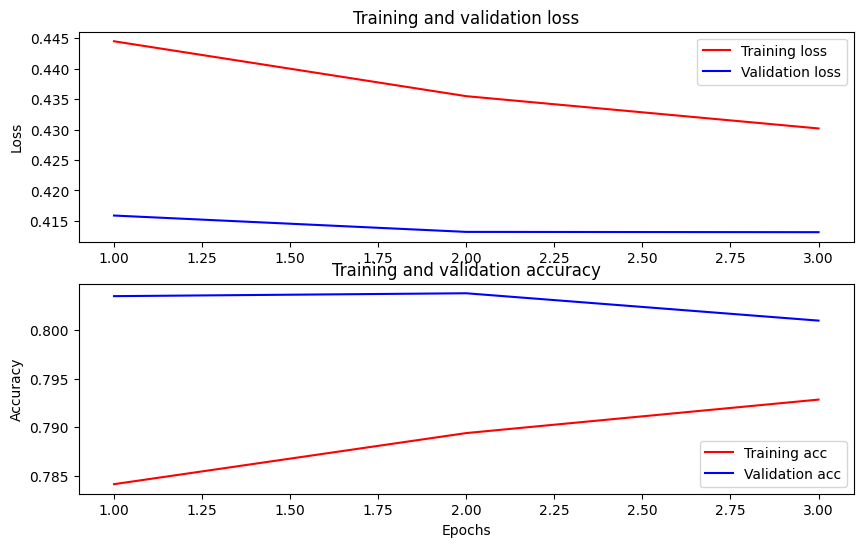

In [ ]:

history_dict = history1.history
print(history_dict.keys())

acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)
fig = plt.figure(figsize=(10, 6))
fig.tight_layout()

plt.subplot(2, 1, 1)
# r is for "solid red line"
plt.plot(epochs, loss, 'r', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
# plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(epochs, acc, 'r', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])


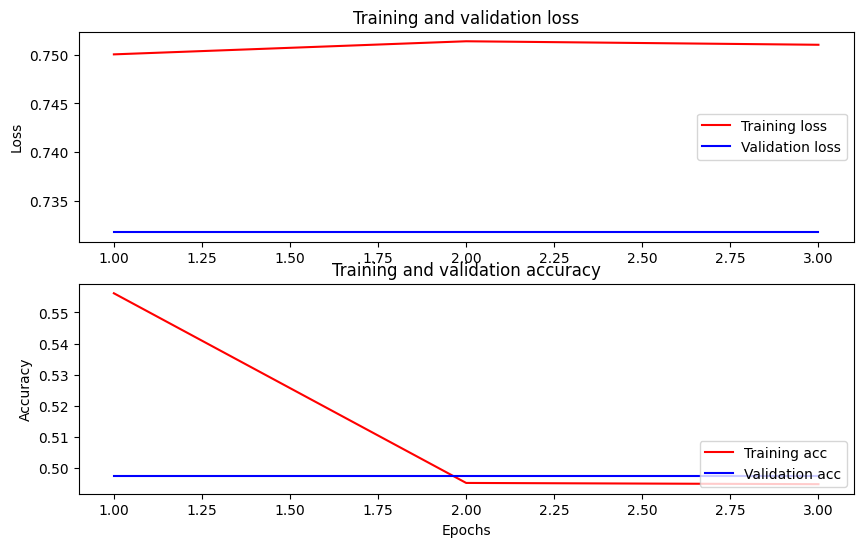

In [ ]:

history_dict = history2.history
print(history_dict.keys())

acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)
fig = plt.figure(figsize=(10, 6))
fig.tight_layout()

plt.subplot(2, 1, 1)
# r is for "solid red line"
plt.plot(epochs, loss, 'r', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
# plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(epochs, acc, 'r', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

Evaluation on the training instances

In [30]:
loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)
metrics = tf.keras.metrics.BinaryAccuracy()
classifier_model_short, local_model_path, drive_model_path = changeSet("config_1")
classifier_model_short.compile(optimizer=optimizer, loss=loss, metrics=[metrics])
loss, accuracy = classifier_model_short.evaluate(test_ds)
print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

✅ Model config_1 already exists. Loading...
Model loaded successfully.
75/75 [==============================] - 83s 1s/step - loss: 0.4114 - binary_accuracy: 0.8033
Loss: 0.4114032983779907
Accuracy: 0.8032535314559937


In [31]:
loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)
metrics = tf.keras.metrics.BinaryAccuracy()
classifier_model_long, local_model_path, drive_model_path = changeSet("config_2")
classifier_model_long.compile(optimizer=optimizer, loss=loss, metrics=[metrics])
loss, accuracy = classifier_model_long.evaluate(test_ds)
print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

✅ Model config_2 already exists. Loading...
Model loaded successfully.
75/75 [==============================] - 81s 1s/step - loss: 0.7307 - binary_accuracy: 0.4979
Loss: 0.7307448983192444
Accuracy: 0.4978998601436615


Get the performance on some instances

In [32]:
def print_my_examples(inputs, results):
  result_for_printing = \
    [f'input: {inputs[i]:<30} : score: {results[i][0]:.6f}'
                         for i in range(len(inputs))]
  print(*result_for_printing, sep='\n')
  print()

loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)
metrics = tf.keras.metrics.BinaryAccuracy()
classifier_model_short, local_model_path, drive_model_path = changeSet("config_1")

classifier_model_long, local_model_path, drive_model_path = changeSet("config_2")
classifier_model_long.compile(optimizer=optimizer, loss=loss, metrics=[metrics])

examples = [
    'this is such an amazing movie!',  # this is the same sentence tried earlier
    'The movie was great!',
    'The movie was meh.',
    'The movie was ok. .',
    'The movie was terrible...',
    'Just had the most incredible day! 🌟 Started with a refreshing morning walk in the park, surrounded by the beauty of nature and the soothing sounds of birds chirping. Then, I had an amazing coffee meeting with some inspiring colleagues who shared their innovative ideas and positive energy. The afternoon was filled with productive work sessions, and I felt so accomplished after completing a challenging project. To top it all off, I enjoyed a delicious dinner with my loved ones, sharing laughter and heartfelt conversations. Grateful for these moments of joy, connection, and growth. Life is truly beautiful when you embrace every opportunity with an open heart and a positive mindset! 💖 #Gratitude #PositiveVibes #LifeIsGood'
]

# [0] and [1] positive [2] neutral [3] neutral [4] Negative  [5] Long positive
original_results = tf.sigmoid(classifier_model_short(tf.constant(examples)))
print('Results from the model in memory from short :')
print_my_examples(examples, original_results)



original_results = tf.sigmoid(classifier_model_long(tf.constant(examples)))
print('Results from the model in memory from long :')
print_my_examples(examples, original_results)



✅ Model config_1 already exists. Loading...
Model loaded successfully.
✅ Model config_2 already exists. Loading...
Model loaded successfully.
Results from the model in memory from short :
input: this is such an amazing movie! : score: 0.985822
input: The movie was great!           : score: 0.986416
input: The movie was meh.             : score: 0.491039
input: The movie was ok. .            : score: 0.901429
input: The movie was terrible...      : score: 0.024347
input: Just had the most incredible day! 🌟 Started with a refreshing morning walk in the park, surrounded by the beauty of nature and the soothing sounds of birds chirping. Then, I had an amazing coffee meeting with some inspiring colleagues who shared their innovative ideas and positive energy. The afternoon was filled with productive work sessions, and I felt so accomplished after completing a challenging project. To top it all off, I enjoyed a delicious dinner with my loved ones, sharing laughter and heartfelt conversations